In [2]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------------------------------ --------- 6.0/8.0 MB 52.4 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 33.0 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -----------------

In [2]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# 1. Cargamos TU archivo procesado
df = pd.read_csv('../data/processed/bearing_1_features.csv')

# Imprimimos la forma para que veas con tus propios ojos que son 984 filas y 5 columnas
print(f"Dimensiones de los datos listos para la IA: {df.shape}")

# 2. Preparamos los datos para la IA
# A la IA no le interesan las palabras (el nombre del archivo), solo los números
X = df[['RMS', 'Peak_to_Peak', 'Kurtosis', 'Skewness']]

# 3. Inicializamos el modelo de IA (Isolation Forest)
# contamination=0.05 significa que estimamos que un 5% de los datos serán anómalos (el final de la vida)
modelo_ia = IsolationForest(contamination=0.05, random_state=42)

# ... El entrenamiento vendrá ahora ...

Dimensiones de los datos listos para la IA: (984, 5)


Dimensiones de los datos listos para la IA: (984, 5)
¡Modelo entrenado con éxito!


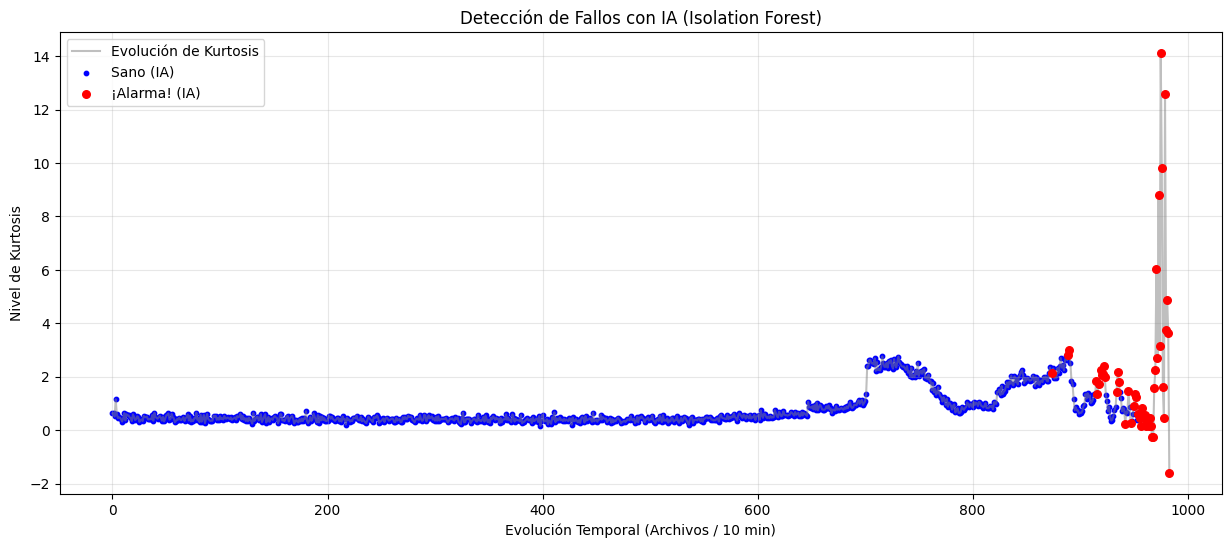

In [4]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# 1. Cargamos TU archivo procesado
df = pd.read_csv('../data/processed/bearing_1_features.csv')

print(f"Dimensiones de los datos listos para la IA: {df.shape}")

# 2. Preparamos los datos
X = df[['RMS', 'Peak_to_Peak', 'Kurtosis', 'Skewness']]

# 3. Inicializamos el modelo de IA
modelo_ia = IsolationForest(contamination=0.05, random_state=42)

# 4. Entrenamos y predecimos
df['Estado_IA'] = modelo_ia.fit_predict(X)
print("¡Modelo entrenado con éxito!")

# --- VISUALIZACIÓN ---
plt.figure(figsize=(15, 6))
sanos = df[df['Estado_IA'] == 1]
anomalos = df[df['Estado_IA'] == -1]

plt.plot(df.index, df['Kurtosis'], color='gray', alpha=0.5, label='Evolución de Kurtosis')
plt.scatter(sanos.index, sanos['Kurtosis'], color='blue', s=10, label='Sano (IA)')
plt.scatter(anomalos.index, anomalos['Kurtosis'], color='red', s=30, label='¡Alarma! (IA)', zorder=5)

plt.title('Detección de Fallos con IA (Isolation Forest)')
plt.xlabel('Evolución Temporal (Archivos / 10 min)')
plt.ylabel('Nivel de Kurtosis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
import joblib
import os

# Creamos la carpeta si no existe
os.makedirs('../models', exist_ok=True)

# Guardamos el modelo entrenado
ruta_modelo = '../models/isolation_forest.joblib'
joblib.dump(modelo_ia, ruta_modelo)

print(f"¡Cerebro guardado exitosamente en: {ruta_modelo}!")

¡Cerebro guardado exitosamente en: ../models/isolation_forest.joblib!


In [4]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import joblib
import os

print("1. Cargando datos...")
df = pd.read_csv('../data/processed/bearing_1_features.csv')
X = df[['RMS', 'Peak_to_Peak', 'Kurtosis', 'Skewness']]

print("2. Creando y ENTRENANDO la IA...")
modelo_ia = IsolationForest(contamination=0.05, random_state=42)
modelo_ia.fit(X) # <-- ¡ESTA ES LA PALABRA MÁGICA QUE FALTABA!

print("3. Guardando el cerebro graduado...")
os.makedirs('../models', exist_ok=True)
joblib.dump(modelo_ia, '../models/isolation_forest.joblib')

print("✅ ¡Éxito! Modelo entrenado y guardado correctamente.")

1. Cargando datos...
2. Creando y ENTRENANDO la IA...
3. Guardando el cerebro graduado...
✅ ¡Éxito! Modelo entrenado y guardado correctamente.
